# CNN

### (1) structure

[input] -> [convolution layer] -> [pooling layer] -> [fully connected layer] -> [output]

- convolution layer

    generate feature map by move kernel according to the stride and multiply some areas of the input data.

    (first layer: detect edgeline, color..)

    (second layer: texture, shape combination..)

    y = (w @ x.T + b)

- activation function

    relu = max(0, x)

- pooling layer

    summurize feature map with max or average ..
    (statical method) 

- fully connected layer

    flatten feature map previous layer and connected MLP structure.

    output = softmax(x)


### (2) data_processing

    list indexing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
data_1 = np.load("./data/data1.npy")
data_2 = np.load("./data/data2.npy")
data_3 = np.load("./data/data3.npy")
data_4 = np.load("./data/data4.npy")

y1 = np.zeros(1000)
y2 = np.full(1000, 1)
y3 = np.full(1000, 2)
y4 = np.full(1000, 3)
labels = np.concatenate((y1, y2, y3, y4))

data_all = np.concatenate((data_1, data_2, data_3, data_4))

idx = np.random.permutation(len(data_all))

data_all = data_all[idx] #list indexing
labels = labels[idx]
labels = labels.astype(int)
print(data_all.shape)

(4000, 12, 12)


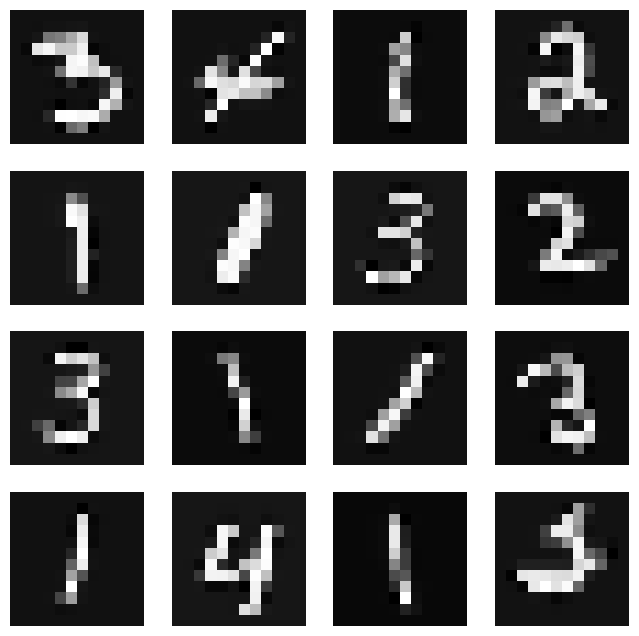

[2 3 0 1 0 0 2 1 2 0 0 2 0 3 0]


In [2]:
plt.figure(figsize = (8,8))
for i in range(16): #for i in range(num_image)
    plt.subplot(4, 4, i+1) #subplot(num_row, num_col, index)
    plt.imshow(data_all[i], cmap = 'gray')
    plt.axis('off')

plt.show()
print(labels[:15])

In [3]:
from model2 import *

x = np.expand_dims(data_all , axis = 1)
x = torch.tensor(x, dtype = torch.float32)
y = torch.tensor(labels, dtype = torch.long)
x.shape

torch.Size([4000, 1, 12, 12])

In [4]:
model = CNN(num_classes = 4)
with torch.no_grad():
    out = model.pool(model.conv3(model.conv2(model.conv1(x))))
    print(out.shape)



torch.Size([4000, 32, 3, 3])


In [5]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)
for epoch in range(100):
  optimizer.zero_grad()
  outputs = model(x)
  loss = criterion(outputs , y)
  loss.backward()
  optimizer.step()

  if epoch % 10 == 0:
    print(f'Epoch [{epoch}/100], Loss: {loss.item():.4f}')


Epoch [0/100], Loss: 1.3862
Epoch [10/100], Loss: 1.3855
Epoch [20/100], Loss: 1.3848
Epoch [30/100], Loss: 1.3841
Epoch [40/100], Loss: 1.3834
Epoch [50/100], Loss: 1.3827
Epoch [60/100], Loss: 1.3821
Epoch [70/100], Loss: 1.3814
Epoch [80/100], Loss: 1.3808
Epoch [90/100], Loss: 1.3802
